![](peg.png)

For some reason the peg solitaire game ended up on our table. I played it a couple of times in my younger years and you might have too. The rules are dead simple: take a peg, jump over an adjecent one to a free square and take the other peg away. Try to end up with 1 peg to win.

But it's not so easy and this seemed like a nice opportunity to do some coding. The board has 33 places where pegs can be placed, leading to roughly 8,5 billion potential positions. Because of the start position and the rules not all of these positions can be reached while playing:

In [2]:
#| include: false
# this is a nice trick to install in the active python environment!
# import sys
# !"{sys.executable}" -m pip install --upgrade pip

In [3]:
#| include: false
from collections import defaultdict
from collections import namedtuple
from time import time
from math import factorial
import pandas as pd
import numpy as np
import altair as alt
import pickle


exp = [2**i for i in range(33)]


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Program Files\Python311\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Program Files\Python311\Lib\site-packages\traitlets\config\application.py", line 982, in launch_instance
    app.start()
  File "c:\Program Files\Python311\Lib\site-packages\ipykernel\kernelapp.py", line 712, in start
    self.io_loop.start()
  File "c:\Program Files\Python311\Lib\si

AttributeError: _ARRAY_API not found

In [4]:
#| include: false
opties = open("opties.txt", 'r').readlines()
opties = [[int(ch)-1 for ch in line.split()] for line in opties]


exp = [2**i for i in range(33)]
neigh = defaultdict(list)
for x,y,z in opties: # calculate the check mask and the move mask
    neigh[x].append([exp[y] | exp[z], exp[x] | exp[y] | exp[z]])

def generate(position):
    newpos = set()
    for i in range(33): # for each holes
        if not (exp[i] & position):  # check if it's empty
            for check, move in neigh[i]: # and for each jump that ends there
                if position & check == check:
                    newpos.add(position ^ move)
    return newpos
def generateincrease(position):
    newpos = set()
    for i in range(33): # for each holes
        if exp[i] & position:  # check if it's full
            for check, move in neigh[i]: # and for each jump that ends there
                if position & check == 0:
                    newpos.add(position ^ move)
    return newpos


In [5]:
#| include: false
LOADFROMDISK = True

if LOADFROMDISK:
    with open("fullresults_stats.pkl", "rb") as file:
        results = pickle.load(file)

else:
    results = defaultdict(dict)
    start = 2 ** 33 - 1 - (2**16)
    current_positions = {start: 1}
    results[32]['reachable'] = current_positions

    for i in range(32,1, -1):
        t = time()
        newoptions = defaultdict(int)
        deadend = defaultdict(int)
        for option, amount in current_positions.items():
            generated = generate(option)
            if not generated:
                deadend[option] += amount
            else:
                for o in generated:
                    newoptions[o] += amount
        if deadend:
            results[i]['deadend'] = deadend
        current_positions = newoptions
        results[i-1]['reachable'] = current_positions
        print('new step', i-1, 'positions', len(current_positions), 'mathemetical options', time()-t)  
        

    with open("results.pkl", "wb") as f:
        pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

In [6]:
#| include: false
# this is calculating the winning options, but that explodes memory once you get to 200M positions
# if not LOADFROMDISK:
#     current_positions = exp
#     results[1]['winning'] = set(exp)
#     # generate winning positions
#     for i in range(1, 10):
#         t = time()
#         newwinningoptions = set()
#         for option in current_positions:
#             newwinningoptions |= generateincrease(option)
#         results[i+1]['winning'] = newwinningoptions
#         current_positions = newwinningoptions
#         print(f'{i+1}, winning {len(newwinningoptions)}, time {time()-t}')

In [7]:
#| include: false
if not LOADFROMDISK:
    # generate winning_reachable positions
    results[1]['reachable_winning'] = list(results[1]['reachable'].keys())

    current_positions = results[1]['reachable_winning']
    for i in range(1, 32):
        t = time()
        newwinningoptions = set()
        print(i)
        for option in current_positions:
            newwinningoptions |= generateincrease(option)

        # print(f'{i+1} balls, {len(newwinningoptions)} winning options, {len(results[i+1]['reachable'])} reachable options, {len(newwinningoptions & results[i+1]['reachable'])} winning and reachable')
        results[i+1]['winning_but_not_sure_reachable'] = newwinningoptions
        current_positions = newwinningoptions & set(results[i+1]['reachable'].keys())
        results[i+1]['reachable_winning'] = current_positions

In [8]:
#| include: false
if not LOADFROMDISK:
    percent_left = 1
    for i in range(32,0,-1):
        hundred_percent = sum(results[i]['reachable'].values())
        cnt_winning, cnt_losing_deadend, cnt_losing_no_deadend = 0,0,0
        for k,amount in results[i]['reachable'].items():
            if k in results[i]['reachable_winning']:
                cnt_winning += amount
            elif 'deadend' in results[i] and k in results[i]['deadend']:
                cnt_losing_deadend += amount
            else:
                cnt_losing_no_deadend += amount
        assert hundred_percent == cnt_winning + cnt_losing_deadend + cnt_losing_no_deadend
        
        results[i]['cnt_winning'] = cnt_winning #/ hundred_percent
        results[i]['cnt_losing_no_dead_end'] = cnt_losing_no_deadend #/ hundred_percent
        results[i]['cnt_losing_dead_end'] = cnt_losing_deadend #/ hundred_percent
        results[i]['pct_winning'] = percent_left * cnt_winning / hundred_percent
        results[i]['pct_losing_no_dead_end'] = percent_left * cnt_losing_no_deadend / hundred_percent
        results[i]['pct_losing_dead_end'] = percent_left * cnt_losing_deadend / hundred_percent
        
        percent_left = percent_left = results[i]['pct_winning'] + results[i]['pct_losing_no_dead_end']
        results[i]['percent_left'] = percent_left
        print(i, percent_left)
    
    

In [9]:
#| include: false
if not LOADFROMDISK:
    current_left = 1
    results[1]['% plays in winning state'] = current_left

    for i in range(32,1, -1):
        current_positions = results[i]['reachable_winning']
        winning, losing = 0,0
        for option in current_positions:
            amount = results[i]['reachable'][option]
            generated = generate(option)
            for o in generated:
                if o in results[i-1]['reachable_winning']:
                    winning += amount / len(generated)
                else:
                    losing += amount / len(generated)
        results[i]['% chance to go winning'] = winning / (winning + losing)
        results[i]['# winning'] = winning
        results[i]['# losing'] = losing
        results[i-1]['% plays in winning state'] = current_left

        current_left *= (winning / (winning + losing))
        
        print(i, winning, losing, winning / (winning + losing), current_left)
                    
results[1]['% plays in winning state'] = results[2]['% plays in winning state']

            


In [10]:
#| include: false
for i in range(1,33):
    if 'deadend' not in results[i]:
        d = []
    else:
        d = results[i]['deadend']
    results[i]['reachable_losing'] = len(results[i]['reachable']) - len(results[i]['reachable_winning']) - len(d)
    if results[i]['reachable_losing'] == 0:
        del results[i]['reachable_losing']
        

# with open("fullresults_stats.pkl", "wb") as f:
#     pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

In [11]:
#| echo: false
data = pd.DataFrame(
    [(i, round(factorial(33) / (factorial(i) * factorial(33 - i)))) for i in range(1,33)],
    columns=["#pegs", "Potential positions"]
)

def add_column(description):
    if isinstance(description, tuple):
        description, name = description
    else:
        name = description
    if isinstance(results[4][description], int) or isinstance(results[2][description], float):
        data[name] = data['#pegs'].map({i:results[i][description] for i in range(1,33) if description in results[i]})
    else:
        data[name] = data['#pegs'].map({i:len(results[i][description]) for i in range(1,33) if description in results[i]})
    
add_columns = [('reachable', 'Reachable positions'), ('reachable_winning', 'Reachable and winning'), ('deadend', 'Reachable and dead end'), 'pct_winning', 'pct_losing_no_dead_end', ('pct_losing_dead_end', '% Games at a dead end'),'cnt_winning', 'cnt_losing_no_dead_end', 'cnt_losing_dead_end', ('percent_left', '% Games unfinished'), ('reachable_losing', 'Reachable and losing'), ('% plays in winning state', 'Cumulative chance to win'), ('% chance to go winning', 'Chance to pick a winning move')]

for description in add_columns:
    add_column(description)
    




In [12]:
#| echo: false
plot_columns = ['#pegs', 'Reachable positions', 'Potential positions']
df = data[plot_columns].melt(
    id_vars='#pegs',           # column(s) to keep as-is
    var_name='Legend',        # name for the new "category" column
    value_name='#'        # name for the new "value" column
)

alt.Chart(df).mark_line(point=True).encode(
    x=alt.X("#pegs:O", title="Number of pegs left", scale=alt.Scale(reverse=True)),
    y=alt.Y("#:Q", title="Positions", scale=alt.Scale(type="log")),
    color='Legend:N'
).properties(width=500, height=300)

alt.Chart(...)

Note that in this chart the y-axis is logaritmic instead of linear. The blue line shows you all ways you could place pegs without minding any rules. For example, you can arrange the 32 starting pegs + 1 free spot in 33 potential ways. In the real game with 32 pegs there is only 1 position that is reachable: the start position. That's why the orange line is lower. After the initial move, there are 4 reachable positions with 31 pegs and this 'escalates' quite quickly. 

Let's now investigate these reachable positions further. They can be divided into 3 different types:
* Winning positions from where you can still reach the winning end with 1 peg
* Dead ends, where you cannot move anymore. 
* Losing positions, where you will eventually hit a dead end before you win the game. 

While playing you might not know if you are in a winning or losing position. You will notice a dead end though.

In [13]:
#| echo: false
plot_columns = ['#pegs', 'Reachable and winning', 'Reachable and losing','Reachable and dead end']

df = data[plot_columns].melt(
    id_vars='#pegs',
    var_name='Legend',
    value_name='#'
)

alt.Chart(df).mark_line(point=True).encode(
    x=alt.X("#pegs:O", title="Number of pegs left", scale=alt.Scale(reverse=True)),
    y=alt.Y("#:Q", title="Positions", scale=alt.Scale(type="log")),
    color=alt.Color(
        "Legend:N",
        scale=alt.Scale(
            domain=['Reachable and winning', 'Reachable and losing','Reachable and dead end'],
            range=['green', 'red', 'purple']
        )
    )
).properties(width=500, height=300)

alt.Chart(...)

Some observations:
* The first couple of moves from 32 - 29 there are no reachable losing positions, so any moves you make are still winning
* Eventually there are way more losing positions 
* There is a purple dot at 26 pegs, which shows it's possible to reach a dead end after only 6 moves. It's a nice exercise to try to reach it from the start position

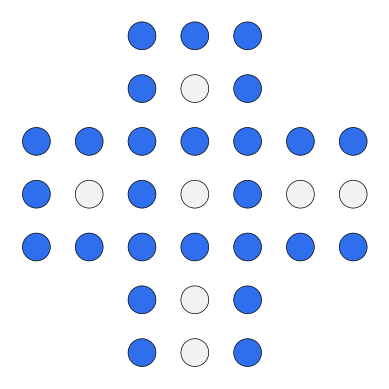

In [14]:
#| include: false
 
from ipywidgets import interact
from matplotlib import animation, rc, cm
from matplotlib.colors import ListedColormap
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt

# | export

        
forbidden = {0,1,5,6,7,8,12,13,35,36,40,41,42,43,47,48}
exp = {i:2**i for i in range(33)}
cmap = ListedColormap(["#f2f2f2", "#f2f2f2", "#2f6fed"])

def plot(grid, ax=None):
    if isinstance(grid, list):
        grid = np.array(grid)
    rows, cols = grid.shape

    if ax is None:
        fig, ax = plt.subplots()

    ax.set_facecolor("white")

    ys, xs = np.meshgrid(range(rows), range(cols), indexing="ij")
    ys, xs, vals = ys.flatten(), xs.flatten(), grid.flatten()

    mask = vals != 0
    ax.scatter(xs[mask], ys[mask], c=cmap(vals[mask]),
               s=400, edgecolors="black", linewidths=0.5)

    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(rows - 0.5, -0.5)  # flip y to match imshow orientation
    ax.set_aspect("equal")
    ax.axis("off")

def grid(pos):
    maze = [[0 for j in range(7)] for i in range(7)]
    cur = 0
    for i in range(49):
        if i not in forbidden:
            if exp[cur] & pos:
                maze[i//7][i%7] = 2
            else:
                maze[i//7][i%7] = 1
            cur += 1
    return maze


plot(grid(next(iter(results[26]['deadend']))))

* There are 4 winning positions with 2 pegs left, but 5 winning positions with 1 peg. That sounds strange untill you see it:

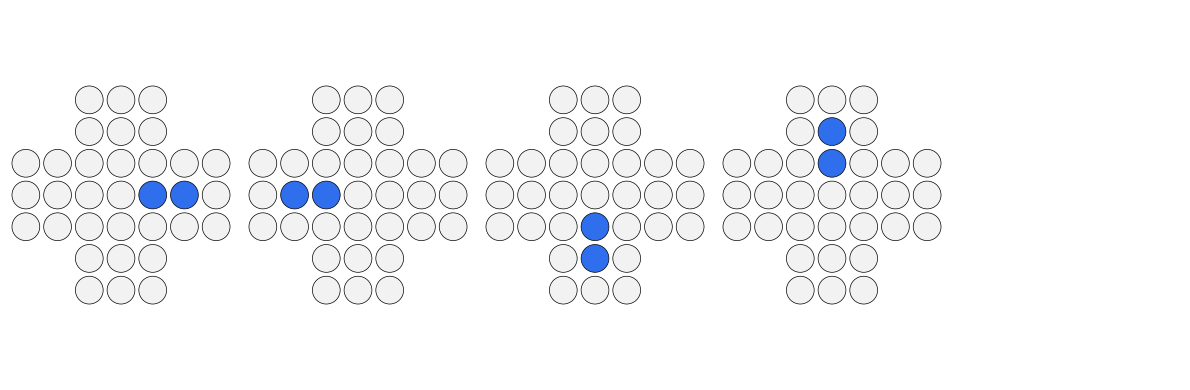

In [15]:
#| echo: false
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for ax, win in zip(axes, results[2]['reachable_winning']):
    plot(grid(win), ax)
for ax in axes[4:]:
    ax.axis("off")
    
plt.tight_layout()
plt.show()

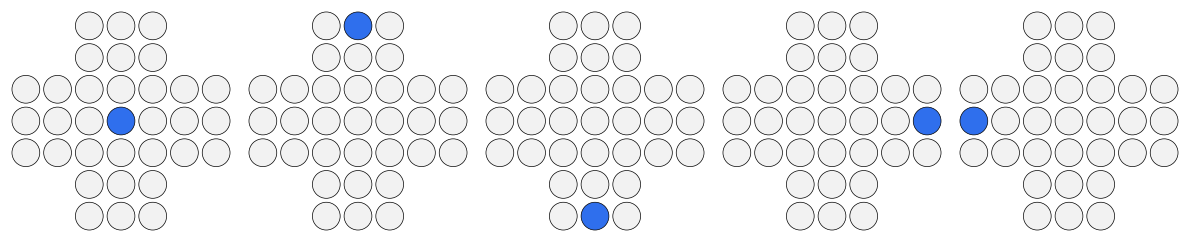

In [16]:
#| echo: false
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for ax, win in zip(axes, results[1]['reachable_winning']):
    plot(grid(win), ax)
plt.tight_layout()
plt.show()

These are the **only** winning positions you can reach.

How do games proceed in practice if you would play randomly?


In [17]:
#| echo: false
plot_columns = ['#pegs', '% Games at a dead end', '% Games unfinished']
df = data[plot_columns].melt(
    id_vars='#pegs',           # column(s) to keep as-is
    var_name='Legend',        # name for the new "category" column
    value_name='#'        # name for the new "value" column
)
alt.Chart(df).mark_line(point=True).encode(
    x=alt.X("#pegs:O", title="Number of pegs left", scale=alt.Scale(reverse=True)),
    y=alt.Y("#:Q", title="",  axis=alt.Axis(format=".0%"), scale=alt.Scale(type="linear")),
    color='Legend:N'
).properties(width=500, height=300)

alt.Chart(...)

The blue line shows that given a position, how high the chance it's a dead end. The yellow line is cumulative: how high is the chance a game is still unfinished (you are still alive) with a certain number of pegs left. 50% of the games end with 6 or more pegs. Therefore, if you finish with 5 pegs or fewer you are doing better then average. You have 0,001% to end up with 2 or even 1 peg winning the game. That's.... not great.

This chart showed when the game will end. What's also interesting is if you are in a potential winning position, or in an effectively losing position where you can no longer end with 1 peg:

In [18]:
#| include: false
sum(results[i]['pct_losing_dead_end'] for i in range(32,5,-1))

0.5090133022399096

In [19]:
#| echo: false
plot_columns = ['#pegs', 'Cumulative chance to win', 'Chance to pick a winning move']
df = data[plot_columns].melt(
    id_vars='#pegs',           # column(s) to keep as-is
    var_name='Legend',        # name for the new "category" column
    value_name='#'        # name for the new "value" column
)
alt.Chart(df).mark_line(point=True).encode(
    x=alt.X("#pegs:O", title="Number of pegs left", scale=alt.Scale(reverse=True)),
    y=alt.Y("#:Q", title="", axis=alt.Axis(format=".0%")),
    color='Legend:N'
).properties(width=500, height=300)

alt.Chart(...)

The blue line shows the chance you have of making a move that still keeps you in a winning state. As mentioned, in the beginning you cannot make a wrong move, but after 20 pegs left many time you have 40% chance to pick a winning continuation. When you have 2 pegs left in a winning position you cannot make a mistake anymore.

The yellow line shows you the cumulative chance you are still winning. With 18 pegs left, you have <5% chance to still be in a potential winning position.

To close a fun fact: even though it's really hard to reach the final state with 1 peg, there are 81723294080159936 different ways in which you can reach it!

In [20]:
#| include: false
sum(results[1]['reachable'].values())

81723294080159936

In [21]:
#| include: false
winning = [2 ** 33 - 1 - (2**16)]
for i in range(32, 1, -1):
    cur = winning[-1]
    newoptions = generate(cur)
    cur = next(iter(newoptions & set(results[i-1]['reachable_winning'])))
    winning.append(cur)



In [22]:
#| echo: false
# 

import json, uuid
from IPython.display import HTML
import numpy as np



def animate_html(arrs, cell_px=42):
    """
    Interactive slider+canvas viewer for a list of 2D grids.
    Returns an IPython HTML object — works live in Jupyter, and keeps
    working after Quarto renders the notebook to static HTML (e.g. GitHub
    Pages), since it's plain JS/canvas with no kernel dependency.
    """
    uid = uuid.uuid4().hex[:8]
    frames = [np.asarray(g).tolist() for g in arrs]
    n, rows, cols = len(frames), len(frames[0]), len(frames[0][0])
    data_json = json.dumps(frames)
    width, height = cols * cell_px, rows * cell_px

    return HTML(f"""
    <div id="wrap-{uid}" style="font-family:monospace;max-width:420px">
      <canvas id="canvas-{uid}" width="{width}" height="{height}"
              style="width:100%;aspect-ratio:{cols}/{rows};
                     background:#ffffff;border-radius:6px"></canvas>
      <div style="display:flex;align-items:center;gap:10px;margin-top:10px">
        <button id="play-{uid}">▶</button>
        <input id="slider-{uid}" type="range" min="0" max="{n-1}" value="0" step="1" style="flex:1">
        <span id="label-{uid}" style="min-width:70px;text-align:right;font-size:12px;color:#8a8fa3">0 / {n-1}</span>
      </div>
    </div>
    <script>
    (function() {{
      const frames = {data_json};
      const colors = {{1: "#f2f2f2", 2: "#2f6fed"}};
      const CELL = {cell_px};
      const canvas = document.getElementById("canvas-{uid}");
      const ctx = canvas.getContext("2d");
      const slider = document.getElementById("slider-{uid}");
      const label = document.getElementById("label-{uid}");
      const playBtn = document.getElementById("play-{uid}");
      let playing = false, timer = null;

      function draw(i) {{
        const g = frames[i];
        ctx.fillStyle = "#ffffff";
        ctx.fillRect(0, 0, canvas.width, canvas.height);
        for (let r = 0; r < g.length; r++) {{
          for (let c = 0; c < g[0].length; c++) {{
            const v = g[r][c];
            if (v === 0) continue; // not part of the board
            ctx.fillStyle = colors[v] || "#000";
            ctx.beginPath();
            ctx.arc(c * CELL + CELL / 2, r * CELL + CELL / 2, CELL * 0.35, 0, Math.PI * 2);
            ctx.fill();
            ctx.lineWidth = 1;
            ctx.strokeStyle = "#000";
            ctx.stroke();
          }}
        }}
        label.textContent = i + " / {n-1}";
      }}

      slider.addEventListener("input", () => draw(+slider.value));
      playBtn.addEventListener("click", () => {{
        playing = !playing;
        playBtn.textContent = playing ? "⏸" : "▶";
        if (playing) {{
          timer = setInterval(() => {{
            let next = +slider.value + 1;
            if (next > {n-1}) next = 0;
            slider.value = next;
            draw(next);
          }}, 1000);
        }} else clearInterval(timer);
      }});

      draw(0);
    }})();
    </script>
    """)
animate_html([grid(w) for w in winning])

:::{.callout-note}

A technical explanation on the calculations:

I encoded positions as binary numbers with an empty hole as 0 and a filled hole with 1. For example, a certain position with 5 pegs left becomes 00000001001110000000001000. The index of the binary number is the specific position on the board. I manually wrote down all the potential moves. For each position I checked if which moves are possible. Because it's a binary number this can be done quite fast. To find a winning path we first compute all the reachable positions, and once we reach the end we calculate back (with reversed rules) to the starting position. This way we can find all the reachable and winning positions. 

Computing all the reachable positions is doable in ~20 minutes, but calculating back from all winning positions, didn't work (with 200M positions memory was full).

I didn't use the symmetry of the board, that would have reduced the amount of positions to calculate.

:::

:::{.callout-warning}

There is a strategy to win. I didn't look at it because it solves the game. But in case you want to know, [here is one video](https://www.youtube.com/watch?v=_2UKhe1bg-Y&t=1s)

:::